# MST-Based Circuit Discovery on Greater-Than Task with RelP

**Model**: Qwen2-0.5B (Gated MLP architecture)

**Task**: Greater-Than Year Prediction
- Input: "The war lasted from the year 1732 to the year 17"
- Output: Predict valid two-digit end years (years > 32)
- Metric: mean(logit_correct) - mean(logit_incorrect)

**Graph Structure**:
- **Nodes**: MLP neuron activations (gated MLP)
- **Edges**: Allow skip connections! Layer L can connect to ANY previous layer (not just L-1)
  - This reflects the residual stream architecture where information can flow across multiple layers

**Algorithms Compared**: Kruskal MST, Random Spanning Tree, Steiner Tree

## 1. Setup

In [2]:
!pip install -q einops datasets transformers fancy_einsum
!pip install -q networkx matplotlib seaborn pandas numpy
!pip install -q transformer-lens
!pip install -q git+https://github.com/redwoodresearch/Easy-Transformer.git

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 125.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but y

In [3]:
!pip install --force-reinstall "numpy<2.0"

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pytensor 2.35.1 requires numpy>=2.0, but you ha

In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from typing import Dict, Tuple, List, Optional
from dataclasses import dataclass
from collections import defaultdict
import networkx as nx
from networkx.algorithms.approximation import steiner_tree
import random

import transformer_lens
from transformer_lens import HookedTransformer, ActivationCache
from transformer_lens.utils import get_act_name

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: NVIDIA A100-SXM4-80GB
GPU Memory: 85.2 GB


## 2. Configuration

In [2]:
@dataclass
class Config:
    model_name: str = "Qwen/Qwen2-0.5B"  # Gated MLP model
    num_samples: int = 100
    edge_threshold: float = 2.5e-12
    top_k_parents: int = 10  # Top-k parents PER SOURCE LAYER (not just adjacent)
    batch_size: int = 64
    max_layer_gap: int = None  # None = allow all skip connections; set to N to limit to N layers back

config = Config()
print(config)

Config(model_name='Qwen/Qwen2-0.5B', num_samples=100, edge_threshold=2.5e-12, top_k_parents=10, batch_size=64, max_layer_gap=None)


## 3. Load Model (Qwen2-0.5B with Gated MLP)

Qwen2 uses SwiGLU: output = SiLU(gate_proj(x)) * up_proj(x)

In [3]:
print(f"Loading {config.model_name}...")
model = HookedTransformer.from_pretrained(
    config.model_name,
    device=device,
    fold_ln=False,
    center_writing_weights=False,
    center_unembed=False,
)

model.cfg.use_lrp = True
model.cfg.LRP_rules = ['LN-rule', 'Identity-rule', 'Half-rule']
model.cfg.use_attn_result = True
model.cfg.use_attn_in = True
model.cfg.use_split_qkv_input = True
model.cfg.use_hook_mlp_in = True

print(f"Model: {model.cfg.n_layers} layers, d_mlp={model.cfg.d_mlp}")
print(f"Gated MLP: Yes (Qwen2)")
print(f"LRP enabled: {model.cfg.use_lrp}")

Loading Qwen/Qwen2-0.5B...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loaded pretrained model Qwen/Qwen2-0.5B into HookedTransformer
Model: 24 layers, d_mlp=4864
Gated MLP: Yes (Qwen2)
LRP enabled: True


## 4. Create Greater-Than Dataset

In [4]:
class GreaterThanDataset:
    def __init__(self, model, num_samples=100, seed=42):
        self.model = model
        self.tokenizer = model.tokenizer
        self.num_samples = num_samples
        np.random.seed(seed)

        self.start_years = np.random.randint(1, 99, size=num_samples)
        self.corrupted_start_years = np.zeros(num_samples, dtype=int)

        self.clean_prompts = []
        self.corrupted_prompts = []

        for i, yy in enumerate(self.start_years):
            self.clean_prompts.append(f"The war lasted from the year 17{yy:02d} to the year 17")
            corrupted_yy = np.random.randint(1, 99)
            while corrupted_yy == yy:
                corrupted_yy = np.random.randint(1, 99)
            self.corrupted_start_years[i] = corrupted_yy
            self.corrupted_prompts.append(f"The war lasted from the year 17{corrupted_yy:02d} to the year 17")

        self.clean_tokens = model.to_tokens(self.clean_prompts)
        self.corrupted_tokens = model.to_tokens(self.corrupted_prompts)
        self.year_tokens = self._get_year_tokens()

        print(f"Created {num_samples} samples")
        print(f"Example: {self.clean_prompts[0]}")
        print(f"Tokens shape: {self.clean_tokens.shape}")

    def _get_year_tokens(self):
        year_tokens = {}
        for yy in range(100):
            tokens = self.tokenizer.encode(f"{yy:02d}", add_special_tokens=False)
            if len(tokens) >= 1:
                year_tokens[yy] = tokens[0]
        return year_tokens

print(f"Creating Greater-Than dataset...")
dataset = GreaterThanDataset(model, num_samples=config.num_samples)
clean_tokens = dataset.clean_tokens
corrupted_tokens = dataset.corrupted_tokens
start_years = dataset.start_years
year_tokens = dataset.year_tokens
print(f"Year tokens: {len(year_tokens)}")

Creating Greater-Than dataset...
Created 100 samples
Example: The war lasted from the year 1752 to the year 17
Tokens shape: torch.Size([100, 17])
Year tokens: 100


## 5. Greater-Than Metric

In [5]:
import torch.nn.functional as F
def get_logit_diff_greater_than(logits, start_years, year_tokens):
    """ACDC-faithful metric using probabilities.

    Computes: sum(P(year > YY)) - sum(P(year <= YY))
    Higher = better (model predicts correct years)
    """
    probs = F.softmax(logits[:, -1], dim=-1)  # [batch, vocab]

    batch_size = probs.shape[0]
    diffs = []

    for i in range(batch_size):
        yy = start_years[i]
        # P(correct years: > yy)
        correct_ids = [year_tokens[y] for y in range(yy + 1, 100) if y in year_tokens]
        # P(incorrect years: <= yy)
        incorrect_ids = [year_tokens[y] for y in range(0, yy + 1) if y in year_tokens]

        p_correct = probs[i, correct_ids].sum()
        p_incorrect = probs[i, incorrect_ids].sum()
        diffs.append(p_correct - p_incorrect)

    return torch.stack(diffs).mean()

# Test metric
print("Testing metric...")
with torch.no_grad():
    clean_logits = model(clean_tokens.to(device))
    clean_diff = get_logit_diff_greater_than(clean_logits, start_years, year_tokens)
print(f"Clean logit diff: {clean_diff.item():.4f}")

Testing metric...
Clean logit diff: 7.9929


## 6. Node Representation (MLP Neurons)

In [6]:
@dataclass(frozen=True)
class MLPNode:
    """MLP neuron in gated MLP"""
    layer: int
    neuron: int

    def __repr__(self):
        return f"L{self.layer}N{self.neuron}"

    def __lt__(self, other):
        return (self.layer, self.neuron) < (other.layer, other.neuron)

## 7. Extract MLP Activations (Gated MLP)

In [7]:
def extract_mlp_activations_vectorized(model, tokens, use_all_neurons=True, top_k_per_layer=100, batch_size=32):
    """Extract MLP post activations (after gating)"""
    model.eval()
    layer_activations = defaultdict(list)

    print(f"Extracting MLP activations (d_mlp={model.cfg.d_mlp})...")
    for i in tqdm(range(0, len(tokens), batch_size)):
        batch = tokens[i:i+batch_size].to(device)
        with torch.no_grad():
            _, cache = model.run_with_cache(batch)
        for layer in range(model.cfg.n_layers):
            act_name = get_act_name("post", layer)
            layer_activations[layer].append(cache[act_name].cpu())

    print("Processing neurons...")
    node_values = {}
    for layer in tqdm(range(model.cfg.n_layers)):
        all_acts = torch.cat(layer_activations[layer], dim=0)
        if use_all_neurons:
            neurons_to_use = range(all_acts.shape[2])
        else:
            avg_acts = all_acts.abs().mean(dim=(0, 1))
            neurons_to_use = torch.topk(avg_acts, min(top_k_per_layer, len(avg_acts))).indices.cpu().numpy()

        for neuron in neurons_to_use:
            node = MLPNode(layer, int(neuron))
            node_values[node] = all_acts[:, :, neuron].mean().item()

    print(f"Selected {len(node_values)} nodes")
    return node_values

## 8. RelP Edge Computation (WITH SKIP CONNECTIONS)

**Key Change**: Allow edges from layer L to ANY previous layer, not just L-1.
This reflects the residual stream architecture where MLP outputs are added to the residual
and can be read by any downstream component.

For example, Layer 10's MLP can directly read from Layer 2's MLP output via the residual stream.

In [13]:
def get_cache_fwd_and_bwd(model, tokens, metric_fn):
    model.reset_hooks()
    cache, grad_cache = {}, {}

    def fwd_hook(act, hook): cache[hook.name] = act.detach()
    def bwd_hook(act, hook): grad_cache[hook.name] = act.detach()

    filter_fn = lambda name: "_input" not in name
    model.add_hook(filter_fn, fwd_hook, "fwd")
    model.add_hook(filter_fn, bwd_hook, "bwd")

    logits = model(tokens)
    value = metric_fn(logits)
    value.backward()
    model.reset_hooks()
    return value.item(), ActivationCache(cache, model), ActivationCache(grad_cache, model)


def compute_mlp_relp_edges_with_skip_connections(
    model, clean_tokens, corrupted_tokens, start_years, year_tokens,
    node_activations, top_k=10, edge_threshold=0.0, batch_size=32,
    max_layer_gap=None
):
    """
    Compute RelP edges WITH SKIP CONNECTIONS (VECTORIZED).
    """
    model.eval()
    nodes_by_layer = defaultdict(list)
    neuron_indices_by_layer = {}  # layer -> tensor of neuron indices

    for node in node_activations.keys():
        nodes_by_layer[node.layer].append(node)

    # Pre-compute neuron indices per layer for vectorized lookup
    for layer in nodes_by_layer:
        neurons = [node.neuron for node in nodes_by_layer[layer]]
        neuron_indices_by_layer[layer] = torch.tensor(neurons, device=device)

    G = nx.DiGraph()
    for node, value in node_activations.items():
        G.add_node(node, value=value, layer=node.layer)

    n_layers = model.cfg.n_layers
    print(f"Computing RelP edges WITH SKIP CONNECTIONS - VECTORIZED ({len(node_activations)} nodes)...")
    print(f"  Max layer gap: {'unlimited' if max_layer_gap is None else max_layer_gap}")

    # Pre-compute layer pairs
    layer_pairs = []
    for child_layer in range(1, n_layers):
        if max_layer_gap is None:
            parent_layers = range(0, child_layer)
        else:
            parent_layers = range(max(0, child_layer - max_layer_gap), child_layer)
        for parent_layer in parent_layers:
            if child_layer in nodes_by_layer and parent_layer in nodes_by_layer:
                layer_pairs.append((child_layer, parent_layer))

    print(f"  Layer pairs to process: {len(layer_pairs)}")

    # Accumulate edge weights: (parent_layer, parent_idx, child_layer, child_idx) -> weight
    edge_weights = defaultdict(float)
    num_batches = 0

    for i in tqdm(range(0, len(clean_tokens), batch_size)):
        batch_clean = clean_tokens[i:i+batch_size].to(device)
        batch_years = start_years[i:i+batch_size]

        def batch_metric(logits):
            return get_logit_diff_greater_than(logits, batch_years, year_tokens)

        try:
            _, fwd_cache, bwd_cache = get_cache_fwd_and_bwd(model, batch_clean, batch_metric)
        except Exception as e:
            print(f"Batch {i} failed: {e}")
            continue

        # Pre-compute relevance scores for all layers (FULL d_mlp tensors)
        layer_child_rel = {}
        layer_parent_rel = {}

        for layer in range(n_layers):
            act_name = get_act_name("post", layer)
            if act_name in fwd_cache.cache_dict:
                acts = fwd_cache.cache_dict[act_name]
                layer_parent_rel[layer] = acts.abs().mean(dim=(0, 1))  # [d_mlp]

                if act_name in bwd_cache.cache_dict:
                    grads = bwd_cache.cache_dict[act_name]
                    layer_child_rel[layer] = (acts * grads).abs().mean(dim=(0, 1))  # [d_mlp]

        # VECTORIZED: Process all layer pairs
        for child_layer, parent_layer in layer_pairs:
            if child_layer not in layer_child_rel or parent_layer not in layer_parent_rel:
                continue

            child_indices = neuron_indices_by_layer[child_layer]  # [num_child_neurons]
            parent_indices = neuron_indices_by_layer[parent_layer]  # [num_parent_neurons]

            # Get relevance scores for selected neurons only
            child_rel = layer_child_rel[child_layer][child_indices]  # [num_child]
            parent_rel = layer_parent_rel[parent_layer][parent_indices]  # [num_parent]

            # Distance weight
            layer_dist = child_layer - parent_layer
            dist_weight = 1.0 / layer_dist

            # VECTORIZED: Outer product of relevances [num_child, num_parent]
            scores = torch.outer(child_rel, parent_rel) * dist_weight

            # VECTORIZED: Get top-k parents for each child
            k = min(top_k, scores.shape[1])
            top_k_scores, top_k_parent_idx = scores.topk(k, dim=1)  # [num_child, k]

            # Store edges (convert to CPU for dict keys)
            child_nodes = nodes_by_layer[child_layer]
            parent_nodes = nodes_by_layer[parent_layer]

            top_k_scores_cpu = top_k_scores.cpu()
            top_k_parent_idx_cpu = top_k_parent_idx.cpu()

            for c_idx, child_node in enumerate(child_nodes):
                if child_rel[c_idx].item() < edge_threshold:
                    continue
                for k_idx in range(k):
                    p_idx = top_k_parent_idx_cpu[c_idx, k_idx].item()
                    score = top_k_scores_cpu[c_idx, k_idx].item()
                    parent_node = parent_nodes[p_idx]
                    edge_weights[(parent_node, child_node)] += score

        num_batches += 1

    print(f"\nAdding {len(edge_weights)} edges...")

    # Add edges to graph
    gap_counts = defaultdict(int)
    for (parent, child), weight in edge_weights.items():
        avg_weight = weight / max(num_batches, 1)
        if avg_weight > edge_threshold:
            G.add_edge(parent, child, weight=avg_weight, signed_weight=avg_weight)
            gap = child.layer - parent.layer
            gap_counts[gap] += 1

    print(f"\nEdge distribution by layer gap:")
    for gap in sorted(gap_counts.keys()):
        print(f"  Gap {gap}: {gap_counts[gap]} edges")

    print(f"\nFinal graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

## 9. MST and Spanning Tree Algorithms

In [18]:
def compute_mst(G, algorithm='kruskal'):
    print(f"Computing MST ({algorithm}): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    if G.number_of_nodes() == 0: return nx.DiGraph()

    G_und = G.to_undirected()
    for u, v in G_und.edges():
        G_und[u][v]['neg_weight'] = -G_und[u][v].get('weight', 1.0)

    try:
        mst_und = nx.minimum_spanning_tree(G_und, weight='neg_weight', algorithm=algorithm)
        mst = nx.DiGraph()
        mst.add_nodes_from(mst_und.nodes(data=True))
        for u, v in mst_und.edges():
            if G.has_edge(u, v): mst.add_edge(u, v, **G[u][v])
            elif G.has_edge(v, u): mst.add_edge(v, u, **G[v][u])
        print(f"  Result: {mst.number_of_nodes()} nodes, {mst.number_of_edges()} edges")
        return mst
    except Exception as e:
        print(f"  Error: {e}")
        return nx.DiGraph()

def compute_random_spanning_tree(G):
    print(f"Computing Random ST: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    if G.number_of_nodes() == 0: return nx.DiGraph()

    if not nx.is_weakly_connected(G):
        largest_cc = max(nx.weakly_connected_components(G), key=len)
        G = G.subgraph(largest_cc).copy()

    try:
        G_und = G.to_undirected()
        np.random.seed(42)
        for u, v in G_und.edges():
            G_und[u][v]['random_weight'] = np.random.random()

        rand_tree = nx.minimum_spanning_tree(G_und, weight='random_weight')
        rand_dir = nx.DiGraph()
        rand_dir.add_nodes_from(rand_tree.nodes(data=True))
        for u, v in rand_tree.edges():
            if G.has_edge(u, v): rand_dir.add_edge(u, v, **G[u][v])
            elif G.has_edge(v, u): rand_dir.add_edge(v, u, **G[v][u])
        print(f"  Result: {rand_dir.number_of_nodes()} nodes, {rand_dir.number_of_edges()} edges")
        return rand_dir
    except Exception as e:
        print(f"  Error: {e}")
        return nx.DiGraph()

def compute_steiner_tree_nx(G, num_terminals=None):
    print(f"Computing Steiner Tree: {G.number_of_nodes()} nodes")
    if G.number_of_nodes() == 0: return nx.DiGraph()

    node_attrs = {n: abs(d.get('value', 0)) for n, d in G.nodes(data=True)}
    sorted_nodes = sorted(node_attrs.items(), key=lambda x: x[1], reverse=True)

    if num_terminals is None:
        num_terminals = max(10, len(sorted_nodes) // 5)
    num_terminals = min(num_terminals, len(sorted_nodes))
    num_terminals=3000
    terminals = [n for n, _ in sorted_nodes[:num_terminals]]
    print(f"  {len(terminals)} terminals")

    if len(terminals) < 2: return nx.DiGraph()

    try:
        G_und = G.to_undirected()
        if not nx.is_connected(G_und):
            largest_cc = max(nx.connected_components(G_und), key=len)
            G_und = G_und.subgraph(largest_cc).copy()
            terminals = [t for t in terminals if t in G_und]

        if len(terminals) < 2: return nx.DiGraph()

        steiner_und = nx.approximation.steiner_tree(G_und, terminals, weight='weight')
        steiner_dir = nx.DiGraph()
        for n in steiner_und.nodes():
            if n in G.nodes(): steiner_dir.add_node(n, **G.nodes[n])
        for u, v in steiner_und.edges():
            if G.has_edge(u, v): steiner_dir.add_edge(u, v, **G[u][v])
            elif G.has_edge(v, u): steiner_dir.add_edge(v, u, **G[v][u])
        print(f"  Result: {steiner_dir.number_of_nodes()} nodes, {steiner_dir.number_of_edges()} edges")
        return steiner_dir
    except Exception as e:
        print(f"  Error: {e}")
        return nx.DiGraph()

def compute_circuit(G, algorithm):
    if algorithm == "kruskal": return compute_mst(G, 'kruskal')
    elif algorithm == "random_spanning_tree": return compute_random_spanning_tree(G)
    elif algorithm == "steiner": return compute_steiner_tree_nx(G)
    else: raise ValueError(f"Unknown: {algorithm}")

## 10. Run Experiment

In [15]:
print("="*60)
print("STEP 1: EXTRACT MLP ACTIVATIONS")
print("="*60)
node_activations = extract_mlp_activations_vectorized(
    model, clean_tokens, use_all_neurons=True, batch_size=config.batch_size
)
print(f"Total nodes: {len(node_activations)}")

STEP 1: EXTRACT MLP ACTIVATIONS
Extracting MLP activations (d_mlp=4864)...


  0%|          | 0/2 [00:00<?, ?it/s]

Processing neurons...


  0%|          | 0/24 [00:00<?, ?it/s]

Selected 116736 nodes
Total nodes: 116736


In [21]:
print("\n" + "="*60)
print("STEP 2: COMPUTE RELP EDGES (WITH SKIP CONNECTIONS)")
print("="*60)
G = compute_mlp_relp_edges_with_skip_connections(
    model, clean_tokens, corrupted_tokens, start_years, year_tokens,
    node_activations,
    top_k=10, #start with 10 to minimze graph complexity
    edge_threshold= 2.5e-12,
    batch_size=config.batch_size,
    max_layer_gap=5  # start with 5 to not create to big of graph
)


STEP 2: COMPUTE RELP EDGES (WITH SKIP CONNECTIONS)
Computing RelP edges WITH SKIP CONNECTIONS - VECTORIZED (116736 nodes)...
  Max layer gap: 5
  Layer pairs to process: 105


  0%|          | 0/2 [00:00<?, ?it/s]


Adding 5175296 edges...

Edge distribution by layer gap:
  Gap 1: 1133312 edges
  Gap 2: 1084672 edges
  Gap 3: 1036032 edges
  Gap 4: 987392 edges
  Gap 5: 933888 edges

Final graph: 116736 nodes, 5175296 edges


In [22]:
print("\n" + "="*60)
print("STEP 3: COMPUTE CIRCUITS")
print("="*60)
algorithms = ['kruskal', 'random_spanning_tree', 'steiner']
circuits = {}
for algo in algorithms:
    print(f"\n--- {algo.upper()} ---")
    circuits[algo] = compute_circuit(G, algo)


STEP 3: COMPUTE CIRCUITS

--- KRUSKAL ---
Computing MST (kruskal): 116736 nodes, 5175296 edges
  Result: 116736 nodes, 111881 edges

--- RANDOM_SPANNING_TREE ---
Computing Random ST: 116736 nodes, 5175296 edges
  Result: 111882 nodes, 111881 edges

--- STEINER ---
Computing Steiner Tree: 116736 nodes
  3000 terminals
  Result: 3015 nodes, 3014 edges


In [23]:
# Analyze skip connections in discovered circuits
print("\n" + "="*60)
print("SKIP CONNECTION ANALYSIS")
print("="*60)

for algo in algorithms:
    circuit = circuits[algo]
    if circuit.number_of_edges() == 0:
        continue

    print(f"\n{algo.upper()}:")
    gap_counts = defaultdict(int)
    skip_edges = []

    for u, v in circuit.edges():
        if isinstance(u, MLPNode) and isinstance(v, MLPNode):
            gap = abs(v.layer - u.layer)
            gap_counts[gap] += 1
            if gap > 1:
                skip_edges.append((u, v, gap))

    print(f"  Edge distribution by layer gap:")
    for gap in sorted(gap_counts.keys()):
        pct = 100 * gap_counts[gap] / circuit.number_of_edges()
        print(f"    Gap {gap}: {gap_counts[gap]} edges ({pct:.1f}%)")

    if skip_edges:
        print(f"  Notable skip connections (gap > 1):")
        skip_edges.sort(key=lambda x: x[2], reverse=True)
        for u, v, gap in skip_edges[:5]:
            print(f"    {u} -> {v} (gap={gap})")


SKIP CONNECTION ANALYSIS

KRUSKAL:
  Edge distribution by layer gap:
    Gap 1: 82650 edges (73.9%)
    Gap 2: 4879 edges (4.4%)
    Gap 3: 4874 edges (4.4%)
    Gap 4: 9739 edges (8.7%)
    Gap 5: 9739 edges (8.7%)
  Notable skip connections (gap > 1):
    L2N1903 -> L7N4806 (gap=5)
    L2N1903 -> L7N4843 (gap=5)
    L2N1903 -> L7N2617 (gap=5)
    L2N1903 -> L7N2544 (gap=5)
    L2N1903 -> L7N255 (gap=5)

RANDOM_SPANNING_TREE:
  Edge distribution by layer gap:
    Gap 1: 28637 edges (25.6%)
    Gap 2: 23564 edges (21.1%)
    Gap 3: 21474 edges (19.2%)
    Gap 4: 19876 edges (17.8%)
    Gap 5: 18330 edges (16.4%)
  Notable skip connections (gap > 1):
    L0N338 -> L5N2489 (gap=5)
    L0N338 -> L5N2476 (gap=5)
    L0N338 -> L5N3157 (gap=5)
    L0N338 -> L5N3282 (gap=5)
    L0N338 -> L5N49 (gap=5)

STEINER:
  Edge distribution by layer gap:
    Gap 1: 16 edges (0.5%)
    Gap 2: 20 edges (0.7%)
    Gap 3: 562 edges (18.6%)
    Gap 4: 863 edges (28.6%)
    Gap 5: 1553 edges (51.5%)
  Notab

## 11. Evaluation

In [24]:
def ablate_circuit(model, tokens, start_years, year_tokens, circuit_nodes, batch_size=32):
    model.eval()
    metrics = []
    circuit_by_layer = defaultdict(set)
    for node in circuit_nodes:
        if isinstance(node, MLPNode):
            circuit_by_layer[node.layer].add(node.neuron)

    def hook(act, hook):
        layer = hook.layer()
        if layer in circuit_by_layer:
            mask = torch.zeros(act.shape[-1], device=act.device)
            for n in circuit_by_layer[layer]: mask[n] = 1.0
            return act * mask
        return torch.zeros_like(act)

    for i in tqdm(range(0, len(tokens), batch_size), desc="Ablation"):
        batch = tokens[i:i+batch_size].to(device)
        batch_years = start_years[i:i+batch_size]
        hooks = [(get_act_name("post", l), hook) for l in range(model.cfg.n_layers)]
        with torch.no_grad():
            with model.hooks(fwd_hooks=hooks):
                logits = model(batch)
        metrics.append(get_logit_diff_greater_than(logits, batch_years, year_tokens).item())
    return np.mean(metrics)

def ablate_complement(model, tokens, start_years, year_tokens, circuit_nodes, batch_size=32):
    model.eval()
    metrics = []
    circuit_by_layer = defaultdict(set)
    for node in circuit_nodes:
        if isinstance(node, MLPNode):
            circuit_by_layer[node.layer].add(node.neuron)

    def hook(act, hook):
        layer = hook.layer()
        if layer in circuit_by_layer:
            mask = torch.ones(act.shape[-1], device=act.device)
            for n in circuit_by_layer[layer]: mask[n] = 0.0
            return act * mask
        return act

    for i in tqdm(range(0, len(tokens), batch_size), desc="Complement"):
        batch = tokens[i:i+batch_size].to(device)
        batch_years = start_years[i:i+batch_size]
        hooks = [(get_act_name("post", l), hook) for l in range(model.cfg.n_layers)]
        with torch.no_grad():
            with model.hooks(fwd_hooks=hooks):
                logits = model(batch)
        metrics.append(get_logit_diff_greater_than(logits, batch_years, year_tokens).item())
    return np.mean(metrics)

def get_baseline(model, tokens, start_years, year_tokens, batch_size=32):
    model.eval()
    metrics = []
    for i in tqdm(range(0, len(tokens), batch_size), desc="Baseline"):
        batch = tokens[i:i+batch_size].to(device)
        batch_years = start_years[i:i+batch_size]
        with torch.no_grad():
            logits = model(batch)
        metrics.append(get_logit_diff_greater_than(logits, batch_years, year_tokens).item())
    return np.mean(metrics)

In [25]:
print("\n" + "="*60)
print("STEP 4: EVALUATE CIRCUITS")
print("="*60)

baseline = get_baseline(model, clean_tokens, start_years, year_tokens, config.batch_size)
print(f"Baseline: {baseline:.4f}")

zero_perf = ablate_circuit(model, clean_tokens, start_years, year_tokens, set(), config.batch_size)
print(f"Zero baseline: {zero_perf:.4f}")

results = {}
for algo in algorithms:
    circuit = circuits[algo]
    if circuit.number_of_nodes() == 0:
        results[algo] = {'nodes': 0, 'edges': 0, 'faithfulness': 0, 'completeness': 0, 'minimality': 0}
        continue

    nodes = set(circuit.nodes())
    circ_perf = ablate_circuit(model, clean_tokens, start_years, year_tokens, nodes, config.batch_size)
    comp_perf = ablate_complement(model, clean_tokens, start_years, year_tokens, nodes, config.batch_size)

    faith = (circ_perf - zero_perf) / (baseline - zero_perf) if baseline != zero_perf else 0
    complete = 1 - (comp_perf - zero_perf) / (baseline - zero_perf) if baseline != zero_perf else 0
    minim = 1 - len(nodes) / (model.cfg.n_layers * model.cfg.d_mlp)

    results[algo] = {
        'nodes': len(nodes), 'edges': circuit.number_of_edges(),
        'faithfulness': faith, 'completeness': complete, 'minimality': minim
    }
    print(f"\n{algo}: F={faith:.3f}, C={complete:.3f}, M={minim:.3f}")

print("\n" + "="*60)
print(pd.DataFrame(results).T.to_string())


STEP 4: EVALUATE CIRCUITS


Baseline:   0%|          | 0/2 [00:00<?, ?it/s]

Baseline: 7.9225


Ablation:   0%|          | 0/2 [00:00<?, ?it/s]

Zero baseline: -0.0013


...

Complement:   0%|          | 0/2 [00:00<?, ?it/s]


random_spanning_tree: F=-0.013, C=1.000, M=0.042


Ablation:   0%|          | 0/2 [00:00<?, ?it/s]

Complement:   0%|          | 0/2 [00:00<?, ?it/s]


steiner: F=0.003, C=0.910, M=0.974

                         nodes     edges  faithfulness  completeness  minimality
kruskal               116736.0  111881.0      1.000000      1.000000    0.000000
random_spanning_tree  111882.0  111881.0     -0.012632      0.999934    0.041581
steiner                 3015.0    3014.0      0.003463      0.909554    0.974172


## 12. Visualization

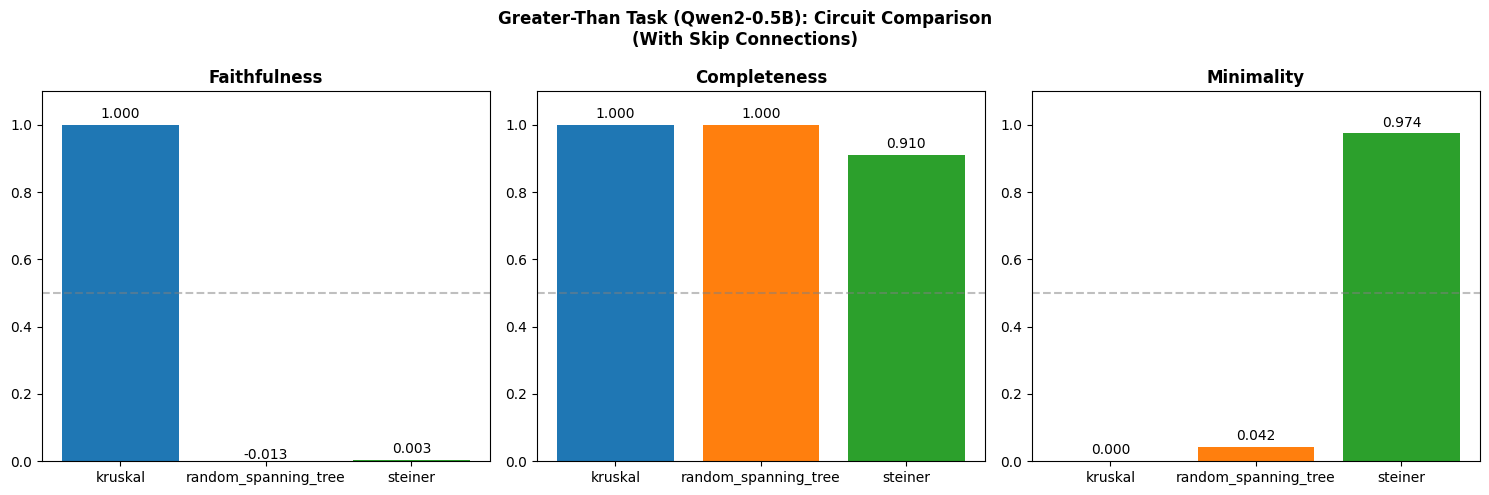

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
metrics = ['faithfulness', 'completeness', 'minimality']
titles = ['Faithfulness', 'Completeness', 'Minimality']

for idx, (m, t) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    vals = [results[a][m] for a in algorithms]
    ax.bar(algorithms, vals, color=colors)
    ax.set_title(t, fontweight='bold')
    ax.set_ylim([0, 1.1])
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.02, f'{v:.3f}', ha='center')

plt.suptitle('Greater-Than Task (Qwen2-0.5B): Circuit Comparison\n(With Skip Connections)', fontweight='bold')
plt.tight_layout()
plt.show()